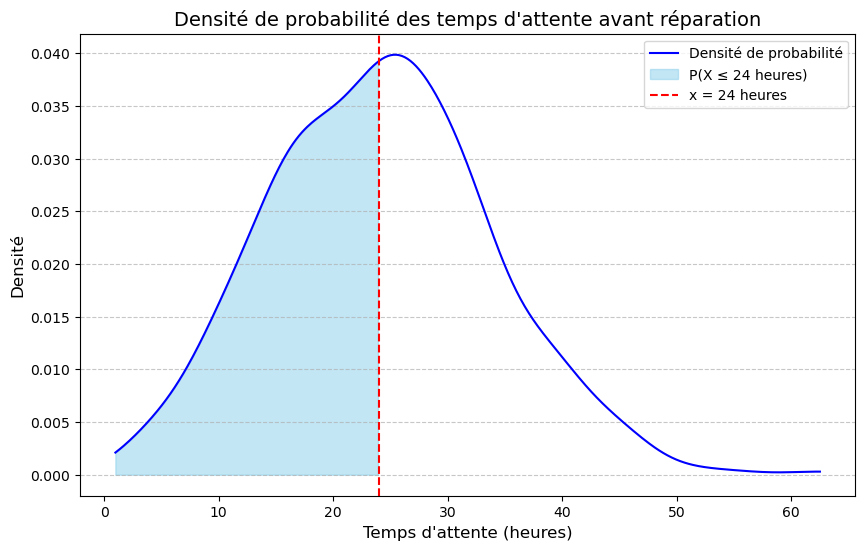

Proportion des réparations en moins de 24 heures : 49.52%


In [2]:
import pandas as pd #Pour la manipulation et l'analyse des données tabulaires (data frame)
import numpy as np #Pour les calculs numériques et la manipulation des tableaux de données.
import matplotlib.pyplot as plt  #Pour tracer les graphiques.
from scipy.stats import gaussian_kde  #Pour estimer la densité de probabilité via la méthode de Kernel Density Estimation (KDE).

# Charger les données depuis le fichier Excel
file_path = r"C:\Users\Windows 11\Desktop\FORMENT_FOTSO\MODELISATION_ORX\Temps_attent_panneServeur_Densite.xlsx"
data = pd.read_excel(file_path)

# Extraction des temps d'attente en heures
temps_attente = data["Temps d'attente (heures)"].values

# Calcul de la densité de probabilité
density = gaussian_kde(temps_attente)
x_vals = np.linspace(temps_attente.min(), temps_attente.max(), 500)
density_vals = density(x_vals)

# Création du graphique de densité
plt.figure(figsize=(10, 6))
plt.plot(x_vals, density_vals, color='blue', label='Densité de probabilité')
plt.fill_between(x_vals, density_vals, where=(x_vals <= 24), color='skyblue', alpha=0.5, label='P(X ≤ 24 heures)')
plt.axvline(24, color='red', linestyle='--', label='x = 24 heures')
plt.title("Densité de probabilité des temps d'attente avant réparation", fontsize=14)
plt.xlabel("Temps d'attente (heures)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calcul de la proportion des réparations en moins de 24 heures
proportion_moins_24 = density.integrate_box_1d(0, 24)
print(f"Proportion des réparations en moins de 24 heures : {proportion_moins_24:.2%}")


In [3]:
data.head()


,Temps d'attente (heures)
0,28.967142
1,22.617357
2,30.476885
3,39.230299
4,21.658466


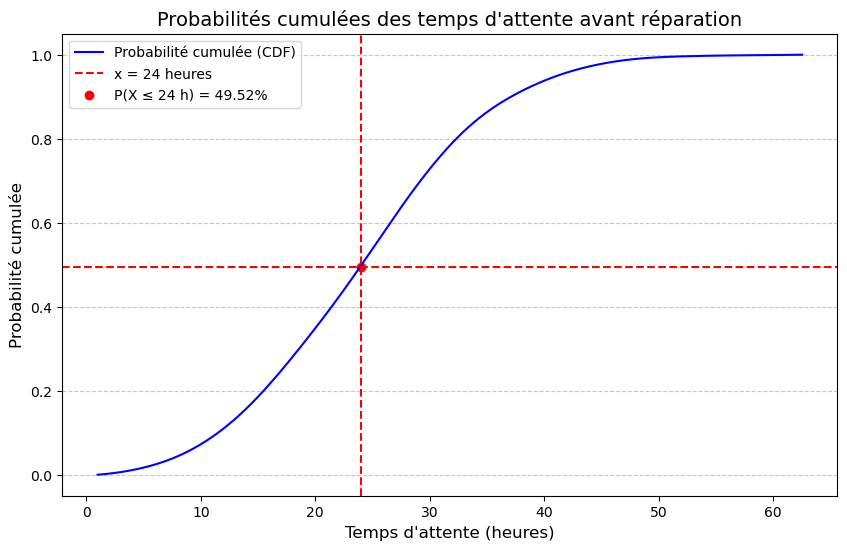

Proportion des réparations en moins de 24 heures (méthode intégrale directe) : 49.52%


In [4]:
# Calcul de la probabilité cumulative pour x ≤ 24 heures (méthode intégrale directe)
probability_24h = density.integrate_box_1d(0, 24)

# Création du graphique de probabilité cumulée
cdf_vals = np.cumsum(density_vals) / np.sum(density_vals)
plt.figure(figsize=(10, 6))
plt.plot(x_vals, cdf_vals, color='blue', label='Probabilité cumulée (CDF)')
plt.axvline(24, color='red', linestyle='--', label='x = 24 heures')
plt.axhline(probability_24h, color='red', linestyle='--')
plt.scatter([24], [probability_24h], color='red', label=f'P(X ≤ 24 h) = {probability_24h:.2%}')

# Configuration du graphique
plt.title("Probabilités cumulées des temps d'attente avant réparation", fontsize=14)
plt.xlabel("Temps d'attente (heures)", fontsize=12)
plt.ylabel("Probabilité cumulée", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Affichage de la probabilité cumulative
print(f"Proportion des réparations en moins de 24 heures (méthode intégrale directe) : {probability_24h:.2%}")



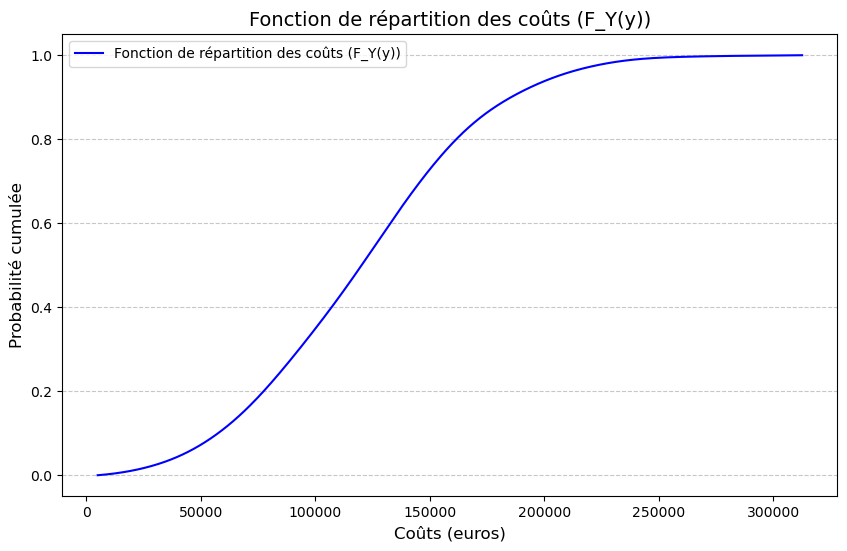

In [5]:
# Transformation des temps d'attente (x_vals) en coûts
cost_vals = 5000 * x_vals  # Y = 5000 * X

# Calcul des probabilités cumulées pour les coûts
cdf_costs = np.cumsum(density_vals) / np.sum(density_vals)

# Création du graphique de la fonction de répartition des coûts
plt.figure(figsize=(10, 6))
plt.plot(cost_vals, cdf_costs, color='blue', label='Fonction de répartition des coûts (F_Y(y))')

# Configuration du graphique
plt.title("Fonction de répartition des coûts (F_Y(y))", fontsize=14)
plt.xlabel("Coûts (euros)", fontsize=12)
plt.ylabel("Probabilité cumulée", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


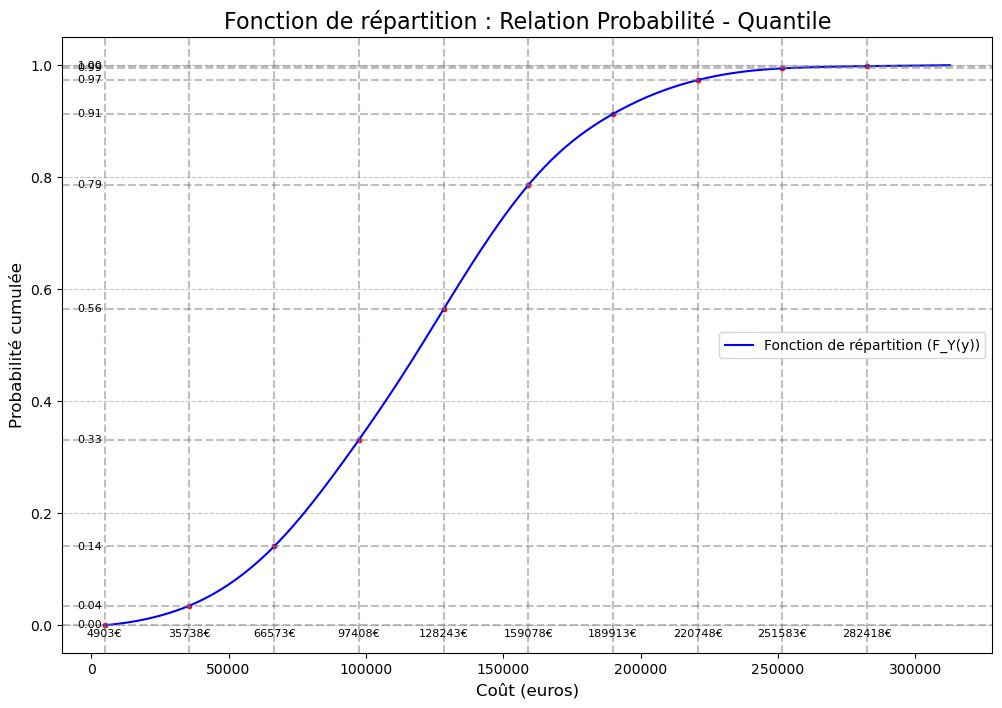

In [10]:
# Création du graphique avec annotations réduites de moitié pour améliorer la lisibilité
plt.figure(figsize=(12, 8))

# Tracé de la fonction de répartition (probabilité cumulée en fonction des coûts)
plt.plot(cost_vals, cdf_costs, color='blue', label='Fonction de répartition (F_Y(y))')

# Ajouter des lignes reliant chaque probabilité à son quantile
for i in range(0, len(cdf_costs), 50):  # Sous-échantillon réduit pour lisibilité
    prob = cdf_costs[i]
    quantile = cost_vals[i]
    
    # Ajouter des lignes de liaison
    plt.axhline(prob, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(quantile, color='gray', linestyle='--', alpha=0.5)
    plt.scatter(quantile, prob, color='red', s=10)  # Ajouter un point à l'intersection
    
    # Ajouter des annotations sur les axes
    plt.text(cost_vals[i], -0.02, f"{int(quantile)}€", fontsize=8, ha='center', color='black')  # Annotation sur l'axe des x
    plt.text(-5000, prob, f"{prob:.2f}", fontsize=8, va='center', color='black')  # Annotation sur l'axe des y

# Configuration du graphique
plt.title("Fonction de répartition : Relation Probabilité - Quantile", fontsize=16)
plt.xlabel("Coût (euros)", fontsize=12)
plt.ylabel("Probabilité cumulée", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()






In [ ]:
P(X< var_alpha)= alpha

F(X_5)= P1 + P2 + P3 + P4 + P5 ,  F(x)= P(X<x)